## Load Libraries

In [1]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.galaxy_bias as bias_module

importlib.reload(bias_module)

# Import functions
from galform_analysis.analysis.correlation import (
    compute_galaxy_bias,
    avg_galaxy_bias_over_subvolumes,
 )

base_dir = get_base_dir()

# Merger tree base directory (edit if needed)
PMILLENNIUM_BASE = Path("/cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps")
SNAP_NUM_BY_IZ = {
    207: 269,  # iz207 -> snapshot 269
}

def tree_file_for(iz_num: int, ivol: int) -> Path:
    snap_num = SNAP_NUM_BY_IZ.get(iz_num)
    if snap_num is None:
        raise KeyError(f"No tree snapshot mapping for iz{iz_num}. Add to SNAP_NUM_BY_IZ.")
    return PMILLENNIUM_BASE / f"treedir_{snap_num}" / f"tree_{snap_num}.{ivol}.hdf5"

# Plotting defaults
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Galaxy Bias for Single Subvolume

In [2]:
# Fetch galaxy bias data for a single snapshot and subvolume
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

# DM halo tree file
tree_file = tree_file_for(207, example_ivol)
print(f"Tree file: {tree_file}")

print(f"Computing galaxy bias for {example_snapshot}, subvolume {example_ivol}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

result = compute_galaxy_bias(
    iz_path=snap_path,
    ivol=example_ivol,
    tree_file=str(tree_file),
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

if result is not None:
    print(f"✓ Data computed successfully")
    print(f"  Redshift: {result.attrs.get('z'):.4f}")
    print(f"  N_galaxies: {result.attrs.get('ngal')}")
    print(f"  N_halos: {result.attrs.get('nhalo')}")
    print(f"  Galaxies per halo: {result.attrs.get('ngal') / result.attrs.get('nhalo'):.2f}")
    print(f"  DM boxsize (Mpc/h): {result.attrs.get('dm_boxsize')}")
else:
    print("✗ Failed to compute galaxy bias")


Tree file: /cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps/treedir_269/tree_269.100.hdf5
Computing galaxy bias for iz207, subvolume 100
Mass cut: M_halo >= 1.0e+11 Msun



[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~490.0 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(


✓ Data computed successfully
  Redshift: 0.4959
  N_galaxies: 6152
  N_halos: 250
  Galaxies per halo: 24.61
  DM boxsize (Mpc/h): 53.789082806440796



   r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
--------------------------------------------------
        0.12   1503.696147  21470.476395     0.265
        0.17    849.886878  17168.888250     0.222
        0.23    483.045247  12066.452056     0.200
        0.32    237.488674   6407.112076     0.193
        0.44    114.567692   3248.794167     0.188
        0.61     51.711762   1693.824910     0.175
        0.85     21.260176    820.905796     0.161
        1.18     10.610138    174.622658     0.246
        1.63      4.942408     24.104865     0.453
        2.28      3.083384      5.064433     0.780
        3.17      1.523394      0.724494     1.450
        4.43      1.005281      2.819700     0.597
        6.15      1.007618      0.773204     1.142
        8.51      1.059229      1.547210     0.827
       11.83      0.976692      0.956021     1.011
       16.41      0.976638      1.077197     0.952
       22.78      0.996249      0.981008     1.008


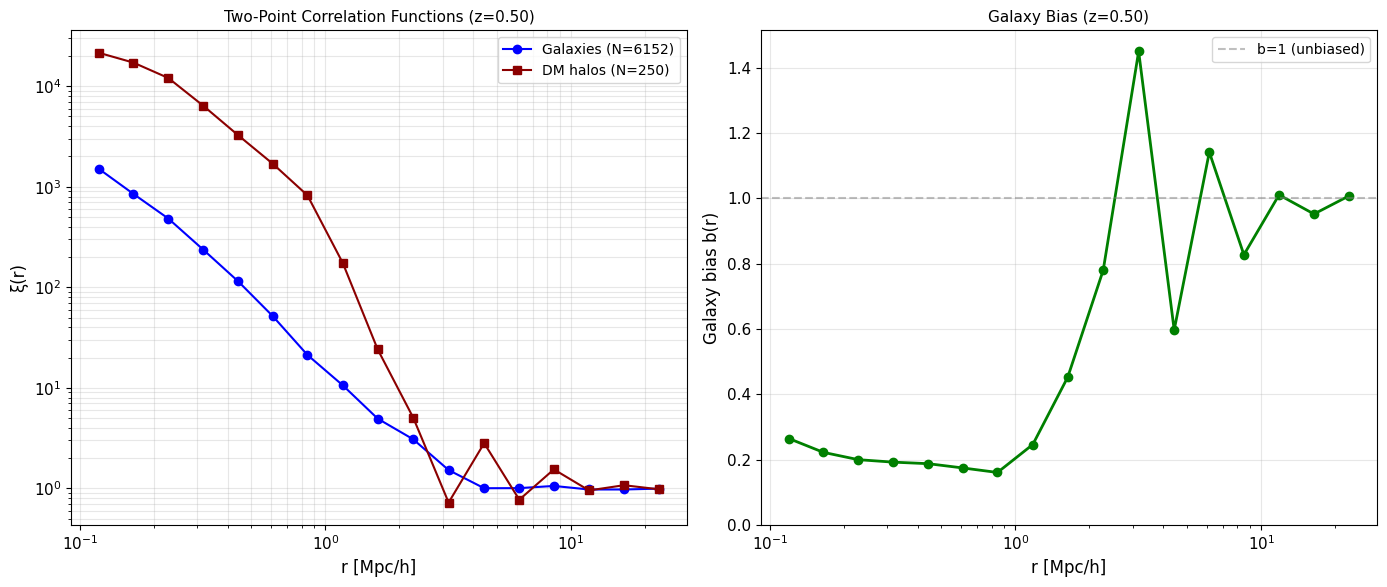

In [3]:
# Plot single subvolume galaxy bias results
if result is not None:
    r = result['r'].to_numpy()
    bias = result['bias'].to_numpy()
    xi_gal = result['xi_gal'].to_numpy()
    xi_dm = result['xi_dm'].to_numpy()
    
    # Create summary table
    mask = np.isfinite(bias)
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("-" * 50)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")
    
    # Two-panel plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Correlation functions (only positive values for log-log)
    ax = axes[0]
    gal_mask = np.isfinite(xi_gal) & (xi_gal > 0)
    dm_mask = np.isfinite(xi_dm) & (xi_dm > 0)
    if gal_mask.any():
        ax.loglog(r[gal_mask], xi_gal[gal_mask], 'o-', color='blue',
                  label=f'Galaxies (N={result.attrs.get("ngal")})', markersize=6)
    else:
        print("Warning: No positive galaxy ξ(r) values to plot on log-log scale.")
    if dm_mask.any():
        ax.loglog(r[dm_mask], xi_dm[dm_mask], 's-', color='darkred',
                  label=f'DM halos (N={result.attrs.get("nhalo")})', markersize=6)
    else:
        print("Warning: No positive DM ξ(r) values to plot on log-log scale.")
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('ξ(r)', fontsize=12)
    ax.set_title(f'Two-Point Correlation Functions (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    # Right: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('Galaxy bias b(r)', fontsize=12)
    ax.set_title(f'Galaxy Bias (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()



   r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
--------------------------------------------------
        0.12   1503.696147  21470.476395     0.265
        0.17    849.886878  17168.888250     0.222
        0.23    483.045247  12066.452056     0.200
        0.32    237.488674   6407.112076     0.193
        0.44    114.567692   3248.794167     0.188
        0.61     51.711762   1693.824910     0.175
        0.85     21.260176    820.905796     0.161
        1.18     10.610138    174.622658     0.246
        1.63      4.942408     24.104865     0.453
        2.28      3.083384      5.064433     0.780
        3.17      1.523394      0.724494     1.450
        4.43      1.005281      2.819700     0.597
        6.15      1.007618      0.773204     1.142
        8.51      1.059229      1.547210     0.827
       11.83      0.976692      0.956021     1.011
       16.41      0.976638      1.077197     0.952
       22.78      0.996249      0.981008     1.008


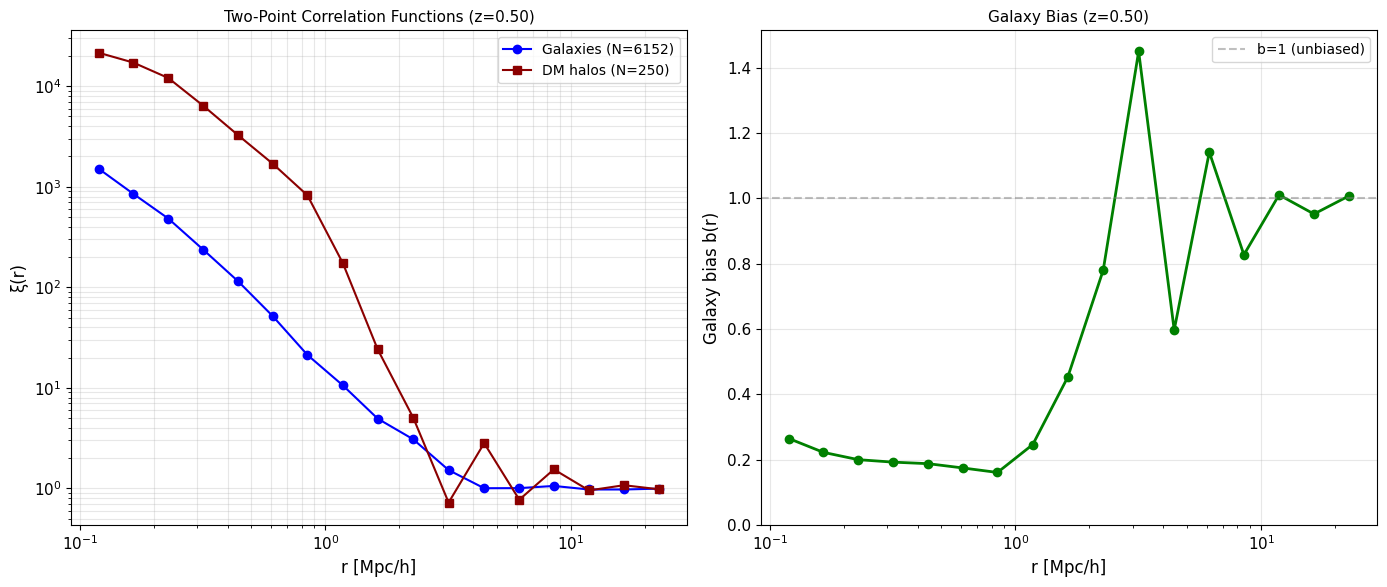

In [4]:
# Plot single subvolume galaxy bias results
if result is not None:
    r = result['r'].to_numpy()
    bias = result['bias'].to_numpy()
    xi_gal = result['xi_gal'].to_numpy()
    xi_dm = result['xi_dm'].to_numpy()
    
    # Create summary table
    mask = np.isfinite(bias)
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("-" * 50)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")
    
    # Two-panel plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Correlation functions (only positive values for log-log)
    ax = axes[0]
    gal_mask = np.isfinite(xi_gal) & (xi_gal > 0)
    dm_mask = np.isfinite(xi_dm) & (xi_dm > 0)
    if gal_mask.any():
        ax.loglog(r[gal_mask], xi_gal[gal_mask], 'o-', color='blue',
                  label=f'Galaxies (N={result.attrs.get("ngal")})', markersize=6)
    else:
        print("Warning: No positive galaxy ξ(r) values to plot on log-log scale.")
    if dm_mask.any():
        ax.loglog(r[dm_mask], xi_dm[dm_mask], 's-', color='darkred',
                  label=f'DM halos (N={result.attrs.get("nhalo")})', markersize=6)
    else:
        print("Warning: No positive DM ξ(r) values to plot on log-log scale.")
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('ξ(r)', fontsize=12)
    ax.set_title(f'Two-Point Correlation Functions (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    # Right: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('Galaxy bias b(r)', fontsize=12)
    ax.set_title(f'Galaxy Bias (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()


## Galaxy Bias Averaged Over Multiple Subvolumes

In [5]:
# Fetch average galaxy bias data over multiple subvolumes
example_snapshot = 'iz207'
snap_path = str(base_dir / example_snapshot)
example_ivols = [40, 60, 100]  # Multiple subvolumes

tree_files = [str(tree_file_for(207, iv)) for iv in example_ivols]

print(f"Computing average galaxy bias for {example_snapshot}")
print(f"Subvolumes: {example_ivols}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

avg_result = avg_galaxy_bias_over_subvolumes(
    iz_path=snap_path,
    ivols=example_ivols,
    tree_files=tree_files,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

if avg_result is not None:
    print(f"✓ Data computed successfully")
    print(f"  Redshift: {avg_result.attrs.get('z'):.4f}")
    print(f"  Subvolumes successful: {avg_result.attrs.get('n_used')}/{avg_result.attrs.get('n_requested')}")
else:
    print("✗ Failed to compute average galaxy bias")


Computing average galaxy bias for iz207
Subvolumes: [40, 60, 100]
Mass cut: M_halo >= 1.0e+11 Msun



/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~483.8 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(
/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~488.9 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(


✓ Data computed successfully
  Redshift: 0.4959
  Subvolumes successful: 3/3



   r [Mpc/h]        bias         std
-----------------------------------
        0.12       0.265       0.002
        0.17       0.317       0.076
        0.23       0.306       0.075
        0.32       0.438       0.231
        0.44       0.396       0.148
        0.62       0.570       0.281
        0.84       0.816       0.477
        1.17       1.693       1.476
        1.64       1.617       0.831
        2.27       1.009       0.380
        3.16       1.166       0.206
        4.41       0.732       0.105
        6.12       0.933       0.160
        8.50       0.835       0.020
       11.83       0.884       0.089
       16.39       0.943       0.012
       22.75       0.992       0.013


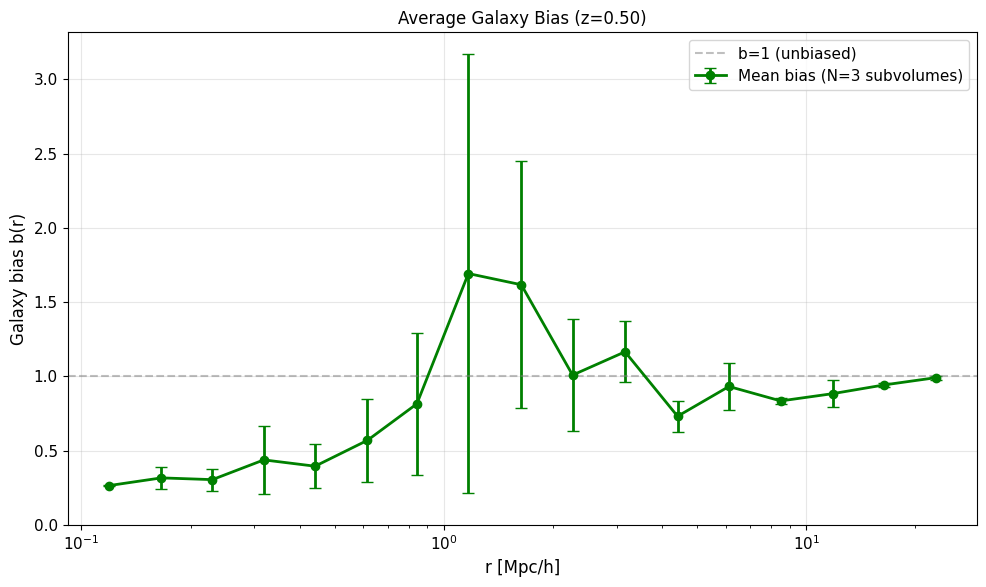

In [6]:
# Plot average bias data over subvolumes
if avg_result is not None:
    r = avg_result['r'].to_numpy()
    bias = avg_result['bias'].to_numpy()
    bias_std = avg_result['bias_std'].to_numpy()
    
    # Create summary table
    mask = np.isfinite(bias)
    print(f"\n{'r [Mpc/h]':>12}  {'bias':>10}  {'std':>10}")
    print("-" * 35)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {bias[i]:10.3f}  {bias_std[i]:10.3f}")
    
    # Plot with error bars
    plt.figure(figsize=(10, 6))
    plt.errorbar(r[mask], bias[mask], yerr=bias_std[mask], 
                 fmt='o-', color='green', markersize=6, linewidth=2,
                 capsize=4, label=f'Mean bias (N={avg_result.attrs.get("n_used")} subvolumes)')
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    plt.xscale('log')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title(f'Average Galaxy Bias (z={avg_result.attrs.get("z"):.2f})', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()


## Galaxy Bias Evolution with Redshift

In [7]:
# Fetch galaxy bias data at multiple redshifts
iz_nums = sorted(SNAP_NUM_BY_IZ.keys())
example_ivol = 100

if len(iz_nums) == 0:
    raise ValueError("SNAP_NUM_BY_IZ is empty. Add iz->snapshot mappings first.")

print("Computing galaxy bias evolution with redshift")
print(f"Snapshots: {[f'iz{iz}' for iz in iz_nums]}")
print(f"Subvolume: {example_ivol}\n")

redshift_results = []
for iz_num in iz_nums:
    snap_path = str(base_dir / f'iz{iz_num}')
    tree_file = tree_file_for(iz_num, example_ivol)
    res = compute_galaxy_bias(
        iz_path=snap_path,
        ivol=example_ivol,
        tree_file=str(tree_file),
        rbins=rbins,
        nthreads=4,
        mhalo_min=mhalo_min,
    )
    if res is not None:
        redshift_results.append(res)
        print(f"✓ iz{iz_num}: z={res.attrs.get('z'):.3f}, N_gal={res.attrs.get('ngal')}, N_halo={res.attrs.get('nhalo')}")
    else:
        print(f"✗ iz{iz_num}: failed")

if len(redshift_results) > 0:
    print(f"\nSuccessfully computed {len(redshift_results)}/{len(iz_nums)} snapshots")
else:
    print("No successful computations")


Computing galaxy bias evolution with redshift
Snapshots: ['iz207']
Subvolume: 100



✓ iz207: z=0.496, N_gal=6152, N_halo=250

Successfully computed 1/1 snapshots


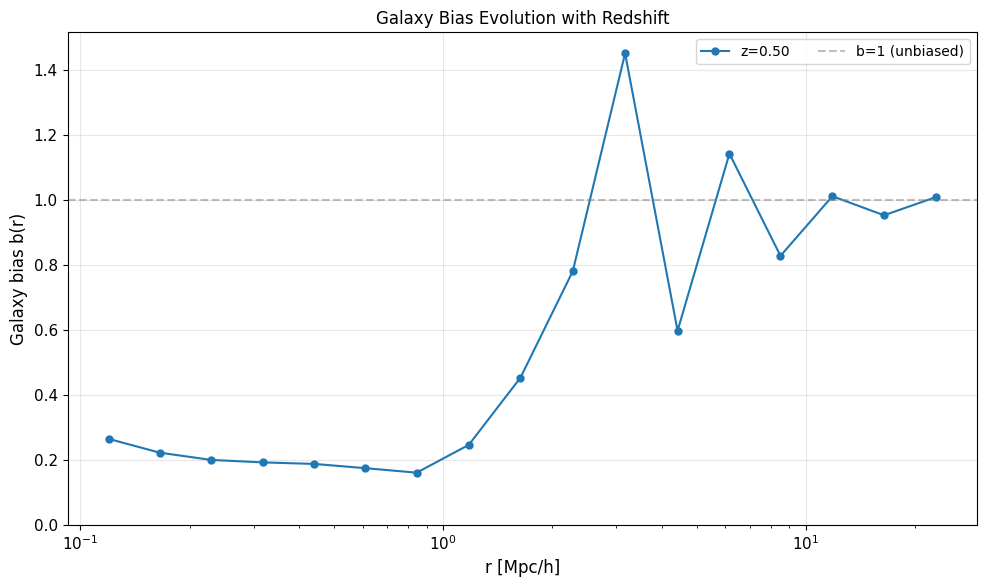

In [9]:
# Plot galaxy bias evolution with redshift
if len(redshift_results) > 0:
    plt.figure(figsize=(10, 6))
    
    for i, res in enumerate(redshift_results):
        r = res["r"].to_numpy()
        bias = res["bias"].to_numpy()
        mask = np.isfinite(bias)
        z = res.attrs.get("z")
        label = f"z={z:.2f}" if z is not None else "z=unknown"
        plt.semilogx(r[mask], bias[mask], 'o-', label=label, markersize=5, linewidth=1.5)
    
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title('Galaxy Bias Evolution with Redshift', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, ncol=2)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("No redshift results to plot")
